In [1]:
# 1) dataset path check
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Find correct dataset path
print(os.listdir('/kaggle/input/datasets/andrewmvd'))
print(os.listdir('/kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k'))

['ocular-disease-recognition-odir5k']
['preprocessed_images', 'ODIR-5K', 'full_df.csv']


In [2]:
# 2) load CSV
BASE_PATH = '/kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k'

df = pd.read_csv(f'{BASE_PATH}/full_df.csv')
print(df.shape)
print(df.columns.tolist())
df.head()

(6392, 19)
['ID', 'Patient Age', 'Patient Sex', 'Left-Fundus', 'Right-Fundus', 'Left-Diagnostic Keywords', 'Right-Diagnostic Keywords', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O', 'filepath', 'labels', 'target', 'filename']


,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O,filepath,labels,target,filename
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",0_right.jpg
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",1_right.jpg
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",2_right.jpg
3,4,53,Male,4_left.jpg,4_right.jpg,macular epiretinal membrane,mild nonproliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",4_right.jpg
4,5,50,Female,5_left.jpg,5_right.jpg,moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",5_right.jpg


In [3]:
# 3) value counts
print(df['target'].value_counts())

target
[1, 0, 0, 0, 0, 0, 0, 0]    2873
[0, 1, 0, 0, 0, 0, 0, 0]    1608
[0, 0, 0, 0, 0, 0, 0, 1]     708
[0, 0, 0, 1, 0, 0, 0, 0]     293
[0, 0, 1, 0, 0, 0, 0, 0]     284
[0, 0, 0, 0, 1, 0, 0, 0]     266
[0, 0, 0, 0, 0, 0, 1, 0]     232
[0, 0, 0, 0, 0, 1, 0, 0]     128
Name: count, dtype: int64


In [4]:
print(df['labels'].value_counts())

labels
['N']    2873
['D']    1608
['O']     708
['C']     293
['G']     284
['A']     266
['M']     232
['H']     128
Name: count, dtype: int64


In [5]:
print(os.listdir(f'{BASE_PATH}/preprocessed_images')[:5])

['3419_left.jpg', '4176_right.jpg', '3370_left.jpg', '1255_right.jpg', '660_left.jpg']


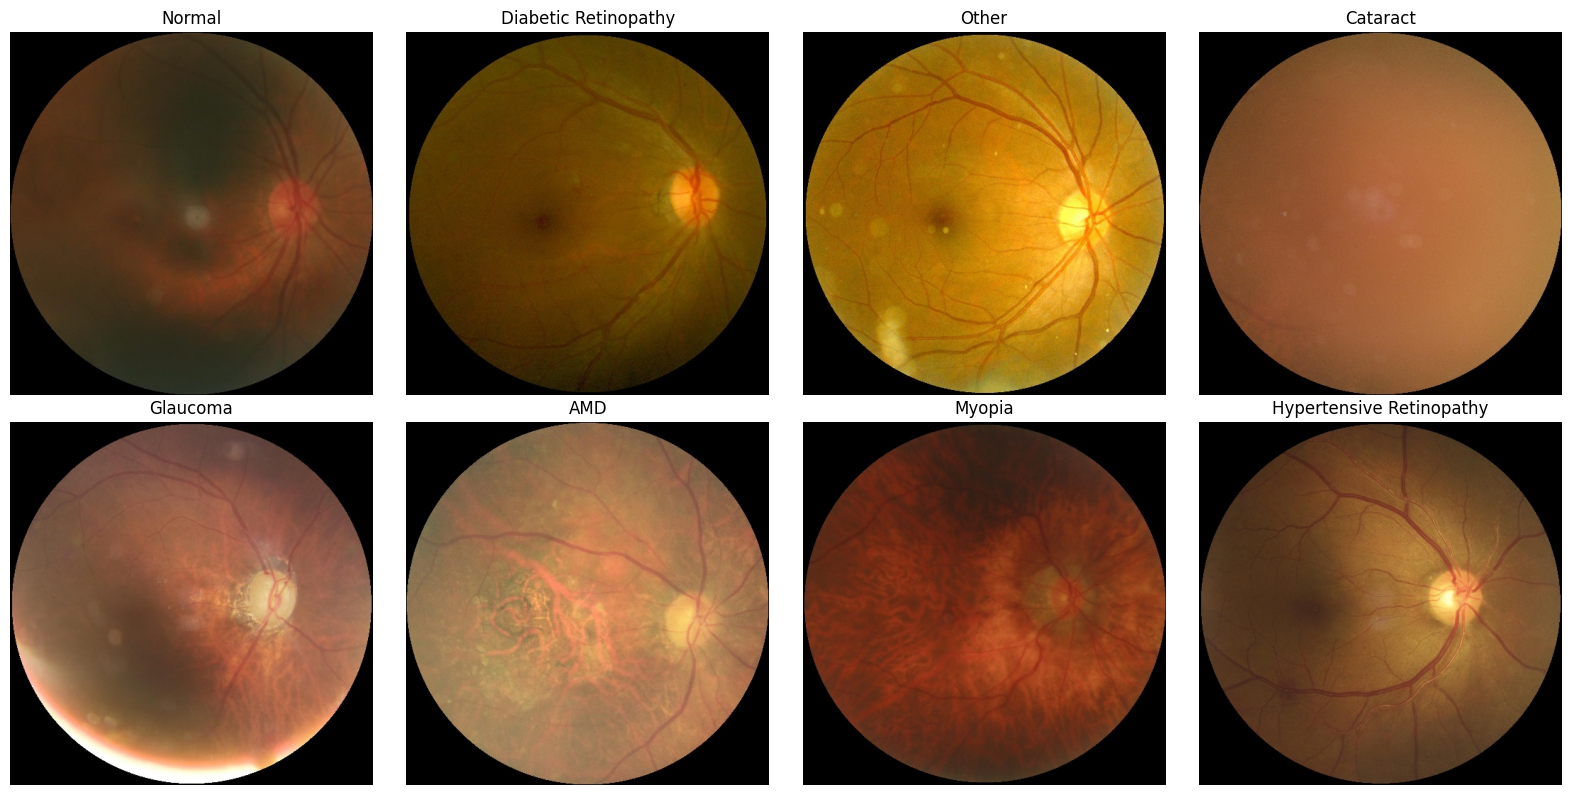

In [6]:
# 4) visualize images
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

disease_map = {'N': 'Normal', 'D': 'Diabetic Retinopathy', 'O': 'Other', 
               'C': 'Cataract', 'G': 'Glaucoma', 'A': 'AMD', 
               'M': 'Myopia', 'H': 'Hypertensive Retinopathy'}

for i, label in enumerate(['N', 'D', 'O', 'C', 'G', 'A', 'M', 'H']):
    sample = df[df['labels'] == f"['{label}']"].iloc[0]
    img_path = f"{BASE_PATH}/preprocessed_images/{sample['filename']}"
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(disease_map[label])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [7]:
# 5) ── Imports & Setup ────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import zipfile
import copy
import ast
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

BASE_PATH = '/kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k'
IMG_DIR   = f'{BASE_PATH}/preprocessed_images'

DISEASE_NAMES = ['Normal', 'Diabetic Retinopathy', 'Glaucoma', 'Cataract',
                 'AMD', 'Hypertensive Retinopathy', 'Myopia', 'Other']
DISEASE_MAP   = {'N': 0, 'D': 1, 'G': 2, 'C': 3, 'A': 4, 'H': 5, 'M': 6, 'O': 7}

Using device: cuda


In [8]:
# 6) ── Patient Leakage Check & Clean 70/15/15 Split ──────────────────────────────

df['label_encoded'] = df['labels'].apply(lambda x: DISEASE_MAP[ast.literal_eval(x)[0]])

# Get unique patient IDs
unique_patients = df['ID'].unique()
print(f"Total unique patients : {len(unique_patients)}")
print(f"Total rows in df      : {len(df)}")
print(f"Rows per patient      : {len(df)/len(unique_patients):.2f} (should be ~2 for left/right eye)")

# Split by PATIENT ID not by row — this prevents leakage
train_ids, temp_ids = train_test_split(unique_patients, test_size=0.30, random_state=42)
val_ids,   test_ids = train_test_split(temp_ids,        test_size=0.50, random_state=42)

train_df = df[df['ID'].isin(train_ids)].reset_index(drop=True)
val_df   = df[df['ID'].isin(val_ids)].reset_index(drop=True)
test_df  = df[df['ID'].isin(test_ids)].reset_index(drop=True)

print(f"\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"\nTrain class distribution:")
print(train_df['label_encoded'].value_counts().sort_index())

# Verify no leakage
train_set = set(train_df['ID'])
val_set   = set(val_df['ID'])
test_set  = set(test_df['ID'])
print(f"\nLeakage check:")
print(f"  Train ∩ Val  : {len(train_set & val_set)}  (should be 0)")
print(f"  Train ∩ Test : {len(train_set & test_set)} (should be 0)")
print(f"  Val ∩ Test   : {len(val_set & test_set)}   (should be 0)")

Total unique patients : 3358
Total rows in df      : 6392
Rows per patient      : 1.90 (should be ~2 for left/right eye)

Train: 4473 | Val: 959 | Test: 960

Train class distribution:
label_encoded
0    2041
1    1108
2     180
3     191
4     199
5     102
6     172
7     480
Name: count, dtype: int64

Leakage check:
  Train ∩ Val  : 0  (should be 0)
  Train ∩ Test : 0 (should be 0)
  Val ∩ Test   : 0   (should be 0)


In [9]:
# 8) ── Transforms, Dataset Class & Dataloaders ───────────────────────────────────

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

inference_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

class ODIRDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df        = dataframe
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['filename'])
        image    = Image.open(img_path).convert('RGB')
        label    = row['label_encoded']
        if self.transform:
            image = self.transform(image)
        return image, label

train_dataset = ODIRDataset(train_df, IMG_DIR, transform=train_transforms)
val_dataset   = ODIRDataset(val_df,   IMG_DIR, transform=inference_transforms)
test_dataset  = ODIRDataset(test_df,  IMG_DIR, transform=inference_transforms)

# Weighted sampler for imbalance
class_counts         = train_df['label_encoded'].value_counts().sort_index().values
class_weights        = 1.0 / class_counts
sample_weights       = [class_weights[l] for l in train_df['label_encoded']]
sampler              = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

print(f"Train: {len(train_loader)} batches | Val: {len(val_loader)} batches | Test: {len(test_loader)} batches")

Train: 140 batches | Val: 30 batches | Test: 30 batches


In [10]:
# 9) ── OcuSense V4 Model Architecture ────────────────────────────────────────────

class OcuSenseV4(nn.Module):
    def __init__(self, num_classes=8):
        super(OcuSenseV4, self).__init__()
        self.backbone = models.efficientnet_b3(weights='IMAGENET1K_V1')
        in_features   = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

model     = OcuSenseV4(num_classes=8).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-6)

class EarlyStopping:
    def __init__(self, patience=7):
        self.patience = patience
        self.counter  = 0
        self.best_acc = 0
        self.stop     = False

    def __call__(self, val_acc):
        if val_acc > self.best_acc:
            self.best_acc = val_acc
            self.counter  = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

print(f"Model ready! Parameters: {sum(p.numel() for p in model.parameters()):,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 128MB/s] 


Model ready! Parameters: 11,091,760


In [11]:
# 10) ── Training Loop ──────────────────────────────────────────────────────────────

NUM_EPOCHS   = 30
best_val_acc = 0.0
early_stop   = EarlyStopping(patience=7)

for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss    += loss.item()
        _, predicted   = outputs.max(1)
        train_correct += predicted.eq(labels).sum().item()
        train_total   += labels.size(0)

    train_acc  = 100. * train_correct / train_total
    train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            val_loss    += loss.item()
            _, predicted = outputs.max(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total   += labels.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_acc  = 100. * val_correct / val_total
    val_loss = val_loss / len(val_loader)
    f1       = f1_score(all_labels, all_preds, average='weighted')

    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '/kaggle/working/ocusense_v4_best.pth')
        print(f"  ★ Best saved! Val Acc: {val_acc:.2f}%")
    
    print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
          f"F1: {f1:.4f}")

    early_stop(val_acc)
    if early_stop.stop:
        print(f"Early stopping at epoch {epoch+1}")
        break

print(f"\nV4 Training Complete! Best Val Acc: {best_val_acc:.2f}%")

  ★ Best saved! Val Acc: 15.64%
Epoch [01/30] Train Loss: 1.1921 | Train Acc: 46.99% | Val Loss: 2.8932 | Val Acc: 15.64% | F1: 0.0820
  ★ Best saved! Val Acc: 18.98%
Epoch [02/30] Train Loss: 0.8087 | Train Acc: 59.31% | Val Loss: 3.0249 | Val Acc: 18.98% | F1: 0.1086
  ★ Best saved! Val Acc: 23.77%
Epoch [03/30] Train Loss: 0.7439 | Train Acc: 63.51% | Val Loss: 2.7397 | Val Acc: 23.77% | F1: 0.1489
  ★ Best saved! Val Acc: 27.53%
Epoch [04/30] Train Loss: 0.6538 | Train Acc: 68.59% | Val Loss: 2.6125 | Val Acc: 27.53% | F1: 0.2225
  ★ Best saved! Val Acc: 33.89%
Epoch [05/30] Train Loss: 0.6204 | Train Acc: 71.79% | Val Loss: 2.6574 | Val Acc: 33.89% | F1: 0.2898
Epoch [06/30] Train Loss: 0.6010 | Train Acc: 73.82% | Val Loss: 2.6290 | Val Acc: 32.01% | F1: 0.2796
  ★ Best saved! Val Acc: 42.23%
Epoch [07/30] Train Loss: 0.5695 | Train Acc: 76.30% | Val Loss: 2.4733 | Val Acc: 42.23% | F1: 0.4080
Epoch [08/30] Train Loss: 0.5482 | Train Acc: 79.45% | Val Loss: 2.5675 | Val Acc: 37.6

Test Accuracy: 59.06%

Classification Report:
                          precision    recall  f1-score   support

                  Normal       0.76      0.50      0.60       444
    Diabetic Retinopathy       0.50      0.67      0.57       240
                Glaucoma       0.47      0.60      0.52        47
                Cataract       0.75      0.96      0.84        48
                     AMD       0.39      0.61      0.47        28
Hypertensive Retinopathy       0.00      0.00      0.00         9
                  Myopia       0.85      0.92      0.88        36
                   Other       0.47      0.58      0.52       108

                accuracy                           0.59       960
               macro avg       0.52      0.60      0.55       960
            weighted avg       0.64      0.59      0.59       960



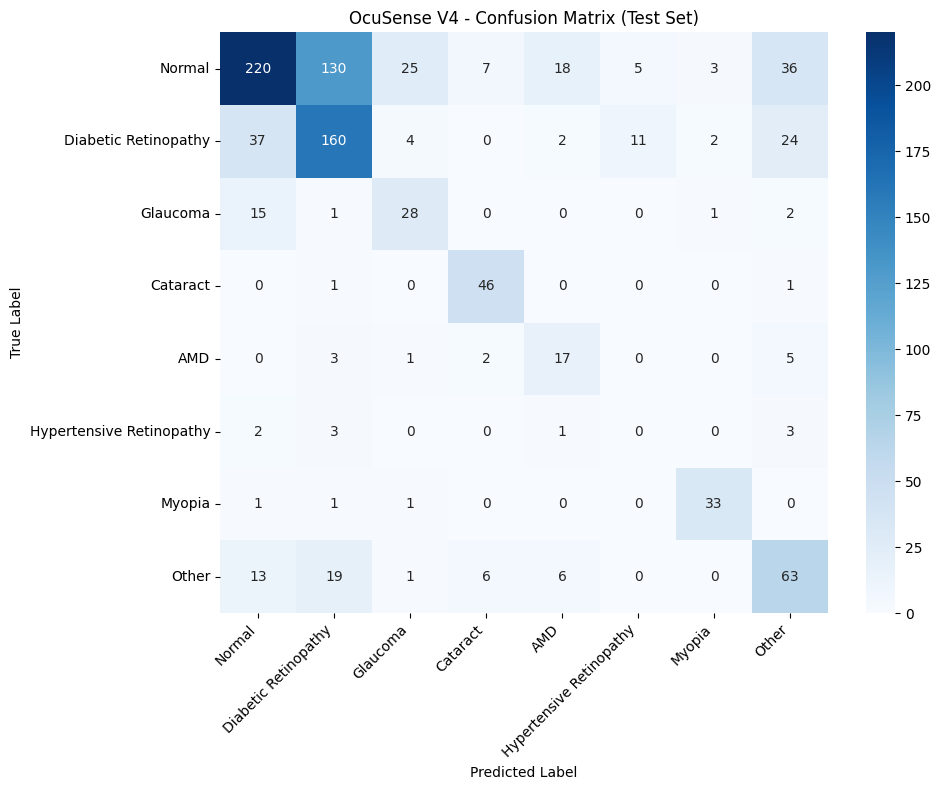

In [12]:
# 11)  ── Final Evaluation on Unseen Test Set ───────────────────────────────────────

model.load_state_dict(torch.load('/kaggle/working/ocusense_v4_best.pth'))
model.eval()

test_correct, test_total = 0, 0
all_preds, all_labels    = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs        = model(images)
        _, predicted   = outputs.max(1)
        test_correct  += predicted.eq(labels).sum().item()
        test_total    += labels.size(0)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = 100. * test_correct / test_total
print(f"Test Accuracy: {test_acc:.2f}%")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=DISEASE_NAMES))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=DISEASE_NAMES, yticklabels=DISEASE_NAMES)
plt.title('OcuSense V4 - Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/kaggle/working/v4_confusion_matrix.png', dpi=150)
plt.show()

In [13]:
# 12) ── Save All Results ───────────────────────────────────────────────────────────

with zipfile.ZipFile('/kaggle/working/ocusense_v4_results.zip', 'w') as zf:
    zf.write('/kaggle/working/ocusense_v4_best.pth',      'ocusense_v4_best.pth')
    zf.write('/kaggle/working/v4_confusion_matrix.png',   'v4_confusion_matrix.png')

print("V4 results saved! Download: ocusense_v4_results.zip")

V4 results saved! Download: ocusense_v4_results.zip
